In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import scipy.stats as stats

In [4]:
df = pd.read_csv("Data/marketing_campaign_1.csv")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [6]:
df.isna().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [7]:
df_ab = df[["ID", "AcceptedCmp1", "AcceptedCmp2"]]
df_ab.head()

,ID,AcceptedCmp1,AcceptedCmp2
0,5524,0,0
1,2174,0,0
2,4141,0,0
3,6182,0,0
4,5324,0,0


In [8]:
df_ab.AcceptedCmp1.value_counts()

AcceptedCmp1
0    2096
1     144
Name: count, dtype: int64

In [9]:
df_ab.AcceptedCmp2.value_counts()

AcceptedCmp2
0    2210
1      30
Name: count, dtype: int64

In [10]:
summary = {
    "Campaign A" : [df_ab["AcceptedCmp1"].mean()*100],
    "Campaign B" : [df_ab["AcceptedCmp2"].mean()*100],
    "Campaign C" : [df["AcceptedCmp3"].mean()*100],
    "Campaign D" : [df["AcceptedCmp4"].mean()*100],
    "Campaign E" : [df["AcceptedCmp5"].mean()*100],
    "Final Campaign" : [df["Response"].mean()*100]
}
pd.DataFrame(summary)

,Campaign A,Campaign B,Campaign C,Campaign D,Campaign E,Final Campaign
0,6.428571,1.339286,7.276786,7.455357,7.276786,14.910714


In [28]:
campaign_a = df.AcceptedCmp1.value_counts()
campaign_b = df.AcceptedCmp2.value_counts()
campaign_c = df.AcceptedCmp3.value_counts()
campaign_d = df.AcceptedCmp4.value_counts()
campaign_e = df.AcceptedCmp5.value_counts()
final_campaign = df.Response.value_counts()

In [29]:
campaign_a,campaign_b,campaign_c,campaign_d, campaign_e, final_campaign


(AcceptedCmp1
 0    2096
 1     144
 Name: count, dtype: int64,
 AcceptedCmp2
 0    2210
 1      30
 Name: count, dtype: int64,
 AcceptedCmp3
 0    2077
 1     163
 Name: count, dtype: int64,
 AcceptedCmp4
 0    2073
 1     167
 Name: count, dtype: int64,
 AcceptedCmp5
 0    2077
 1     163
 Name: count, dtype: int64,
 Response
 0    1906
 1     334
 Name: count, dtype: int64)

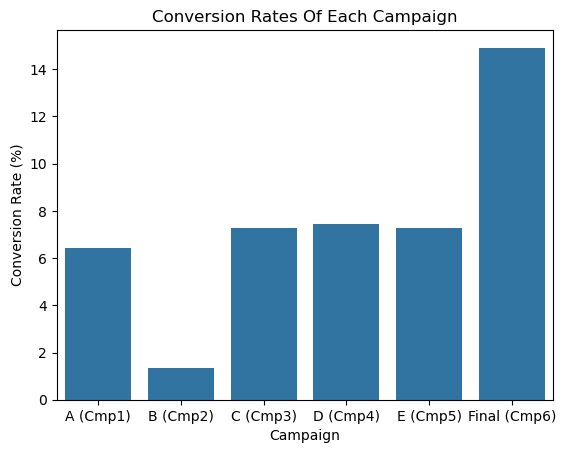

In [27]:
conversion_rates = pd.DataFrame({
    "Campaign": ["A (Cmp1)", "B (Cmp2)", "C (Cmp3)", "D (Cmp4)", "E (Cmp5)", "Final (Cmp6)"],
    "ConversionRate": [
        df["AcceptedCmp1"].mean()*100,
        df["AcceptedCmp2"].mean()*100,
        df["AcceptedCmp3"].mean()*100,
        df["AcceptedCmp4"].mean()*100,
        df["AcceptedCmp5"].mean()*100,
        df["Response"].mean()*100
        
    ]
})

sns.barplot(x="Campaign", y="ConversionRate", data=conversion_rates)
plt.ylabel("Conversion Rate (%)")
plt.title("Conversion Rates Of Each Campaign")
plt.show()

In [42]:
# Comparing Final Campaign Vs First Campaign
contingency = np.array([
    [campaign_a.get(1,0), campaign_a.get(0,0)],  # [Converted, Not Converted]
    [final_campaign.get(1,0), final_campaign.get(0,0)]
])

In [43]:
contingency

array([[ 144, 2096],
       [ 334, 1906]])

In [44]:
chi2, p, dof, expected = stats.chi2_contingency(contingency)

print("Chi2:", chi2)
print("p-value:", p)

Chi2: 83.65591262945932
p-value: 5.88838754884313e-20
